<a href="https://colab.research.google.com/github/MAMIDI-SWETHA/DATA-AND-VISUAL-ANALYTICS-USING-AI-/blob/main/DVA_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# 1. ENVIRONMENT SETUP & IMPORTS
# ================================
!pip install -q transformers datasets

import re
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [ ]:
# ================================
# 2. DATASET LOADING
# ================================
dataset = load_dataset("hate_speech_offensive")

df = dataset['train'].to_pandas()

df['label'] = df['class'].map({
    0: "hate",
    1: "offensive",
    2: "normal"
})

df = df[['tweet','label']]
df.columns = ['text','label']

print(df['label'].value_counts())

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24783 [00:00<?, ? examples/s]

label
offensive    19190
normal        4163
hate          1430
Name: count, dtype: int64


In [ ]:
df_balanced = df.groupby('label').apply(lambda x: x.sample(8000, random_state=42, replace=True)).reset_index(drop=True)

print(df_balanced['label'].value_counts())

label
hate         8000
normal       8000
offensive    8000
Name: count, dtype: int64


/tmp/ipykernel_8203/174828569.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('label').apply(lambda x: x.sample(8000, random_state=42, replace=True)).reset_index(drop=True)


Dataset Shape: (24783, 2)

Columns: Index(['text', 'label'], dtype='object')

Sample Data:
                                                text      label
0  !!! RT @mayasolovely: As a woman you shouldn't...     normal
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  offensive
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  offensive
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  offensive
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  offensive

Class Distribution:
label
offensive    19190
normal        4163
hate          1430
Name: count, dtype: int64


/tmp/ipykernel_8203/2180296184.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


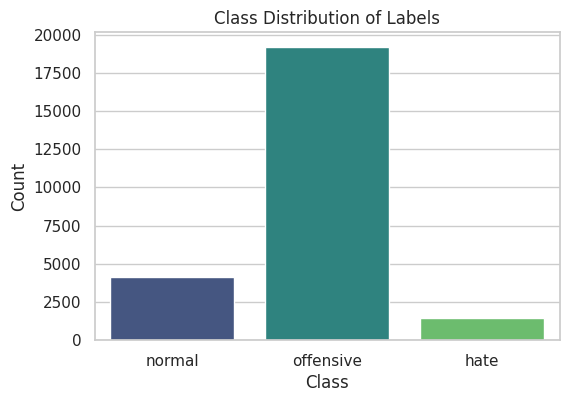

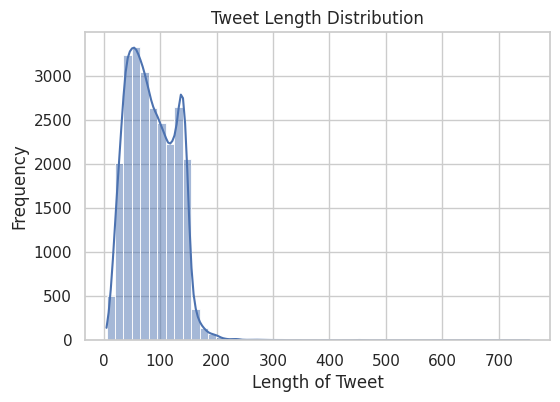

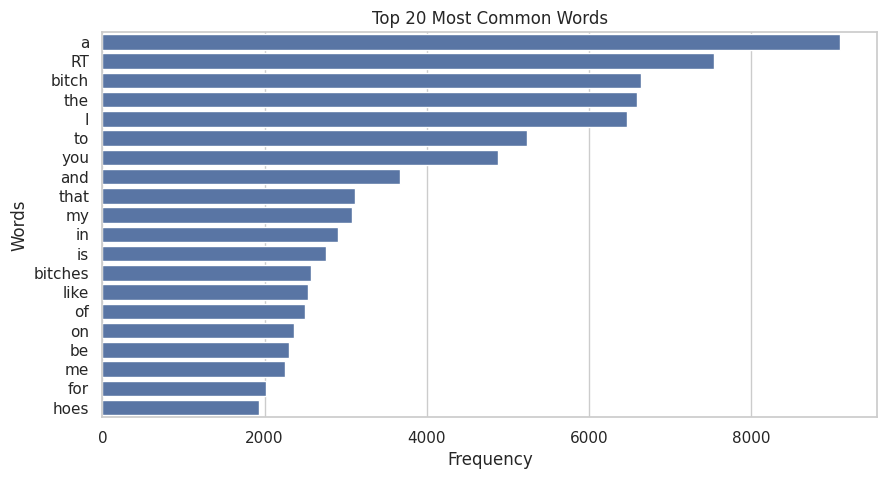

In [ ]:
# ================================
# 3. EXPLORATORY DATA ANALYSIS & VISUALIZATION
# ================================
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nSample Data:")
print(df.head())

print("\nClass Distribution:")
print(df['label'].value_counts())
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title("Class Distribution of Labels")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title("Tweet Length Distribution")
plt.xlabel("Length of Tweet")
plt.ylabel("Frequency")
plt.show()
from collections import Counter

all_words = " ".join(df['text']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [ ]:
# ================================
# 4. DATA PREPROCESSING
# ================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_balanced['clean_text'] = df_balanced['text'].apply(clean_text)

In [ ]:
!pip install -q wordcloud

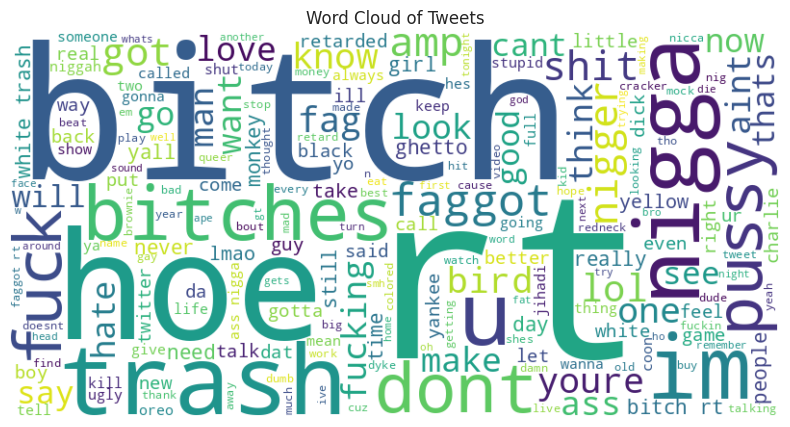

In [ ]:
# ================================
# 5. WORD CLOUD VISUALIZATION
# ================================
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Use a sample to avoid memory overload
sample_text = " ".join(df_balanced['clean_text'].sample(5000, random_state=42))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(sample_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Tweets")
plt.show()

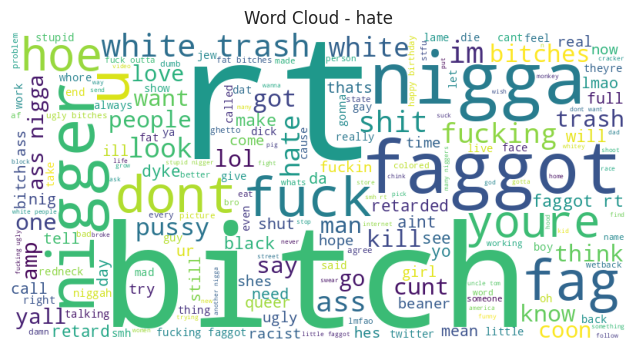

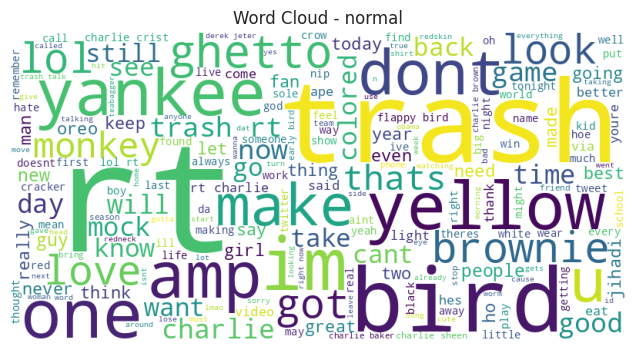

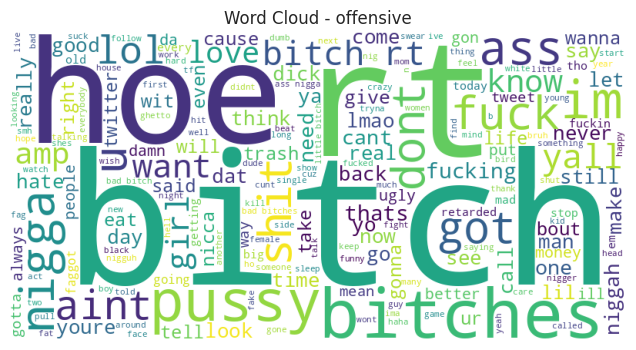

In [ ]:
# 5.1 Class-wise Word Clouds
for label in df_balanced['label'].unique():
    text = " ".join(df_balanced[df_balanced['label']==label]['clean_text'].sample(3000))

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Word Cloud - {label}")
    plt.show()

In [ ]:
# ================================
# 6. LABEL ENCODING
# ================================
label_map = {
    "normal":0,
    "offensive":1,
    "hate":2
}

df_balanced['label_id'] = df_balanced['label'].map(label_map)

In [ ]:
# ================================
# 7. DATA BALANCING
# ================================
df_small = df_balanced.sample(20000, random_state=42)

In [ ]:
# ================================
# 8. TOKENIZATION AND DATASET PREPARATION
# ================================
model_name = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

dataset = Dataset.from_pandas(df_small[['clean_text','label_id']])

def tokenize(ex):
    return tokenizer(ex['clean_text'], truncation=True, padding='max_length', max_length=64)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column('label_id', 'labels') # Add this line to rename the column
dataset = dataset.train_test_split(test_size=0.1)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

In [ ]:
# ================================
# 9. MODEL INITIALIZATION AND LABEL CONFIGURATION
# ================================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

model.config.id2label = {
    0: "normal",
    1: "offensive",
    2: "hate"
}

model.config.label2id = {
    "normal":0,
    "offensive":1,
    "hate":2
}

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ================================
# 10. MODEL TRAINING
# ================================
from transformers import DataCollatorWithPadding

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=True,
    logging_steps=100,
    save_strategy="no"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    data_collator=data_collator
)

trainer.train()

Step,Training Loss
100,1.030503
200,0.959255
300,0.819240
400,0.708780
500,0.687034
600,0.673981
700,0.804914
800,0.673698
900,0.559376
1000,0.581526


TrainOutput(global_step=6750, training_loss=0.4474124704996745, metrics={'train_runtime': 834.3728, 'train_samples_per_second': 64.719, 'train_steps_per_second': 8.09, 'total_flos': 1776015569664000.0, 'train_loss': 0.4474124704996745, 'epoch': 3.0})

In [ ]:
# ================================
# 11. PREDICTION FUNCTION
# ================================
def predict(text):
    model.eval()

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    pred_id = torch.argmax(probs).item()

    print("Probabilities:", probs)
    return model.config.id2label[pred_id]

In [ ]:
# ================================
# 12. TESTING & RESULTS
# ================================
print(predict("You are such an idiot"))
print(predict("I hate you"))
print(predict("Have a great day"))

Probabilities: tensor([[8.4438e-04, 1.1537e-02, 9.8762e-01]], device='cuda:0')
hate
Probabilities: tensor([[9.6701e-04, 1.0581e-02, 9.8845e-01]], device='cuda:0')
hate
Probabilities: tensor([[9.9819e-01, 1.5378e-03, 2.6959e-04]], device='cuda:0')
normal
